Different tries of advection for AR eq. with varying advection.
Plotted along with characterstics.

In [32]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from scipy.optimize import root_scalar
from numba import jit
from scipy.integrate import cumulative_trapezoid
from scipy.integrate import trapezoid

In [33]:
#starting points
z0 = np.linspace(-10,100,20)

# time grid
t = np.linspace(0,3,200)

# starting points
z_values = np.linspace(0,150,200)

Numeric solver:

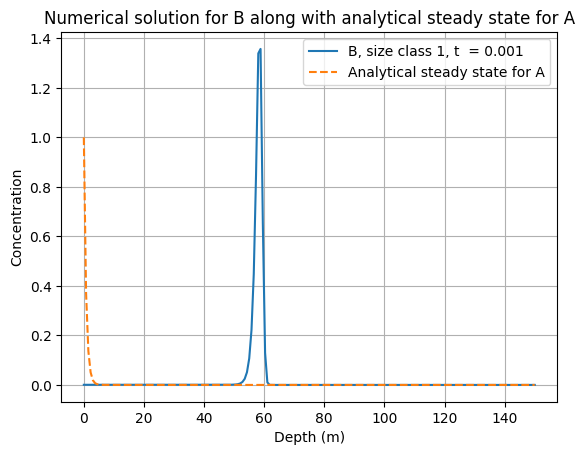

In [34]:
#@jit
# length in meter
L = 150
# reaction rate
alpha= 1.74 # 1/year
# constant diffusion coefficient for particle a
Da = 1
# decay rate for particle b
kappa = 1.42*10**(-2) # 1/year


# number of steps in x direction
Nx = 200
z = np.linspace(0,L,Nx)
u = 10**(-2)+183*10**(5)/(1+np.exp(z-50)) # m/year

umax = np.max(u)


# step length
Dz = L/(Nx-1)
# time steps (chosen based on stability criteria for explicit scheme)
dt = 0.99 * Dz / umax
# number of time steps Nt in years t
T=100*L/umax
end_time = T/(L/umax)
Nt = int(T/ dt)

lamb = np.sqrt(alpha/Da)

# initial condition for b
b = np.zeros_like(z)
# A steady state solution for A
A_st1 = np.exp(-lamb*z)

@jit
def b_solver(b, alpha, kappa, A_st1,dz):
    inv_dz = 1.0 / dz
    for i in range(Nt): # lopping over time steps
        b_new1 = b.copy()
        U_face_prev = 0.5 * (u[0] + u[1])
        B_face_prev = (b[0] if U_face_prev >= 0.0 else b[1])
        F_prev = U_face_prev * B_face_prev
        for j in range(1, Nx-1): # looping over spatial steps
            U1_face_curr = 0.5 * (u[j] + u[j+1])
            B1_face_curr = (b[j] if U1_face_curr >= 0.0 else b[j+1])
            F1_curr = U1_face_curr * B1_face_curr

            # Conservative advection at cell j: -(F_{j+1/2} - F_{j-1/2})/dz
            adv = -(F1_curr - F_prev) * inv_dz

            b_new1[j] = b[j] + dt*(adv+ alpha*A_st1[j]- kappa*b[j])
            F_prev = F1_curr
        b_new1[0] = b_new1[1] # boundary condition at z=0
        b_new1[-1] = 0 # boundary condition at z=L
        b = b_new1.copy() # update b for the next time step
    return b

b = np.zeros_like(z)
b = b_solver(b, alpha, kappa, A_st1, Dz)
# Plotting the results
fig, ax = plt.subplots()
line, = ax.plot(z, b ,label=f"B, size class 1, t  = {Nt*dt:.3f}")
ax.plot(z, A_st1, label='Analytical steady state for A', linestyle='dashed')
ax.set_xlabel('Depth (m)')
ax.set_ylabel('Concentration')
ax.set_title('Numerical solution for B along with analytical steady state for A')
ax.legend()
ax.grid()
plt.show()

Try 1:

$u1(z)=\frac{183}{1+e^{z-50}}$

using method of characteristics. Plotting characteristics $z(t)$, firstly for the advection term just solved numerically.

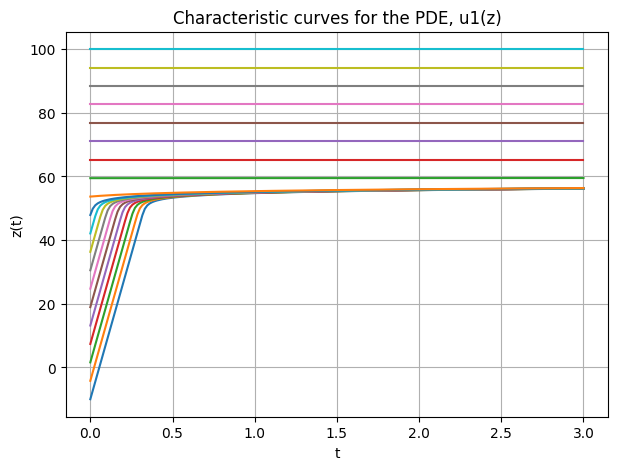

In [35]:

def solve_z(z0, t):

    rhs = z0 + np.exp(z0-50) + 183*t

    f = lambda z: z + np.exp(z-50) - rhs

    sol = root_scalar(f, bracket=[-100, 200], method='brentq') # use brentq because of monotonic behaviour of u
    
    return sol.root

#t = np.linspace(0,3,50)
z = np.array([[solve_z(z0i, ti) for ti in t] for z0i in z0])
plt.figure(figsize=(7,5))
for i in range(len(z0)):
    plt.plot(t, z[i,:])
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title("Characteristic curves for the PDE, u1(z)")
plt.grid()
plt.savefig("C:/Users/sif/OneDrive - Roskilde Universitet/Documents/Mathematical Bioscience/Thesis/Figures/characteristic_lines/characteristics_u1.png", dpi=300)
plt.show()

Plotting solution for B along these characteristics, numerically finding z(t) and inserting in analytical expression for B(z,t).
This is not possible, as overflow is encountered in integrating factor because of exponential of exponential.

Try 2:

$u2(z)=183e^{-0.05z}$

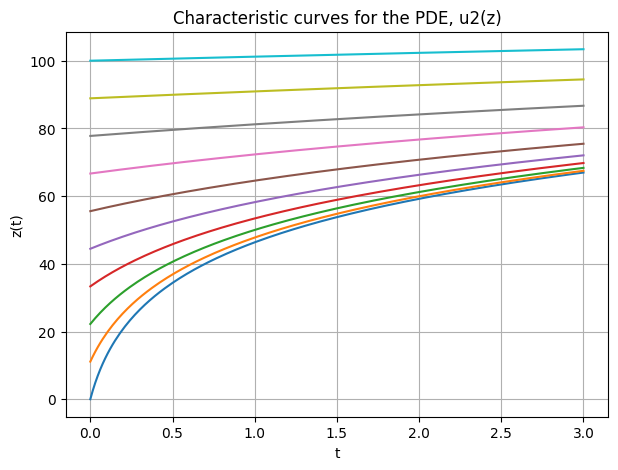

In [45]:
plt.figure(figsize=(7,5))
z = np.zeros((len(t), len(z0)))

for i in range(len(z0)):
    z[:, i] = 20*np.log(np.exp(0.05*z0[i]) + 9.15*t)
    plt.plot(t, z[:, i])



plt.xlabel("t")
plt.ylabel("z(t)")
#plt.legend()
plt.title("Characteristic curves for the PDE, u2(z)")
plt.grid()
plt.savefig("C:/Users/sif/OneDrive - Roskilde Universitet/Documents/Mathematical Bioscience/Thesis/Figures/characteristic_lines/characteristics_u2.png", dpi=300)
plt.show()

This will as well result in overflow

Try 3:

$u3(z)=\frac{183}{1+(\frac{z}{50})^4}$

C:\Users\sif\AppData\Local\Temp\ipykernel_74428\918517900.py:20: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


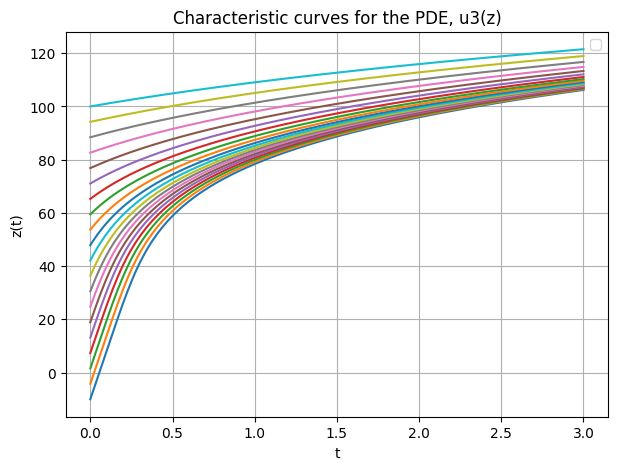

In [37]:
import numpy as np
from scipy.optimize import fsolve

def solve_z(z0,t):

    rhs = z0 + z0**5/(5*50**4) + 183*t

    f = lambda z: z + z**5/(5*50**4) - rhs

    return fsolve(f,z0)[0]

z = np.array([[solve_z(z0i, ti) for ti in t] for z0i in z0])
plt.figure(figsize=(7,5))
for i in range(len(z0)):
    plt.plot(t, z[i,:])
plt.xlabel("t")
plt.ylabel("z(t)")
plt.grid()
plt.title("Characteristic curves for the PDE, u3(z)")
plt.legend()
plt.savefig("C:/Users/sif/OneDrive - Roskilde Universitet/Documents/Mathematical Bioscience/Thesis/Figures/characteristic_lines/characteristics_u3.png", dpi=300)
plt.show()

This as well.


Try 4:

$u4(z)=183-\frac{61}{50}z$

Hopefully this is simple enough to define an explicit analytical solution.

Characteristic lines:
$z(t)=150+(z_0-150)e^{-\frac{61}{50}z}$

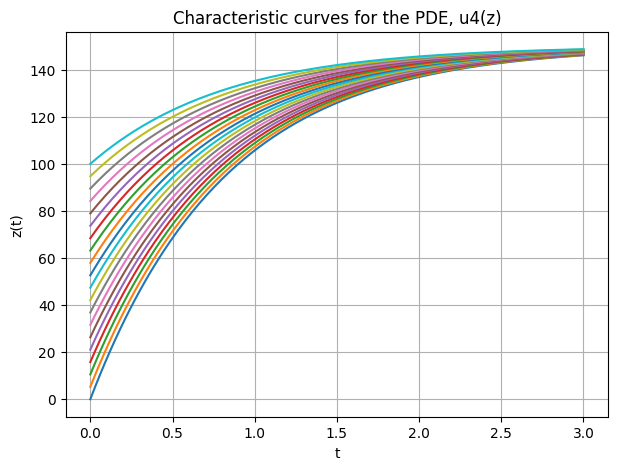

In [ ]:
#starting points
z0 = np.linspace(0,100,20)

# time grid
t = np.linspace(0,3,200)

# starting points
z_values = np.linspace(0,150,200)
z = np.zeros((len(z0), len(t)))

for i in range(len(z0)):
    z[i,:] = 150+(z0[i]-150)*np.exp(244*t)

plt.figure(figsize=(7,5))
for i in range(len(z0)):
    plt.plot(t, z[i,:], label=f"z0={z0[i]:.1f}")
plt.xlabel("t")
plt.ylabel("z(t)")
plt.title("Characteristic curves for the PDE, u4(z)")
plt.savefig("C:/Users/sif/OneDrive - Roskilde Universitet/Documents/Mathematical Bioscience/Thesis/Figures/characteristic_lines/characteristics_u4.png", dpi=300)
#plt.legend()
plt.grid()
plt.show()

This can produce a full analytical solution. plotted in maple.

this is wrong:

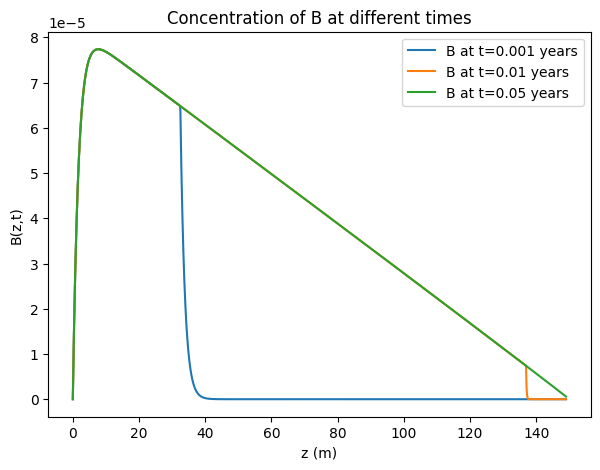

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid

z = np.linspace(0,149,2000)

u = 3.66*10**4 - 244*z

alpha = 1.74
Da = 5
kappa = 1.42e-2

lambda_ = np.sqrt(alpha/Da)

A_st = np.exp(-lambda_*z)

mu = u**( 50/61 * kappa-1)
Q = alpha*A_st/u

# cumulative integral I(z) = ∫0^z μQ dz
I = cumulative_trapezoid(mu*Q, z, initial=0)

def B_solution(t):
    # enforcing dirichlet boundary at top, since u>0 everywhere this is basically no-flux boundary
    #z0 =  150+(z-150)*np.exp(61/50*t)
    #z0 = np.maximum(z0, 0)
    #z0 = np.minimum(z0,150)
    #print(f"z0 range: {z0[0]:.2f} to {z0[-1]:.2f}")

    # interpolate I(z0)
    #I_z0 = np.interp(z0, z, I)

    #B = (I - I_z0) / mu


    z0 = 150 + (z - 150) * np.exp(244 * t)

    B = np.zeros_like(z)

    mask = z0 <= 150

    I_z0 = np.interp(z0[mask], z, I)

    B[mask] = ( I[mask]- I_z0) / mu[mask]

    return B

def B_solution2(t):

    s = np.linspace(0,t,200)

    z_char = 150 + (z[:,None]-150)*np.exp(244*s)

    A_char = np.exp(-lambda_*z_char)

    decay = np.exp(-(kappa-61/50)*s)

    integrand = alpha*A_char*decay

    B = np.trapezoid(integrand,s,axis=1)

    return B
B10 = B_solution(0.001)
B20 = B_solution(0.01)
B50 = B_solution(0.05)

plt.figure(figsize=(7,5))

plt.plot(z, B10, label="B at t=0.001 years")
plt.plot(z, B20, label="B at t=0.01 years")
plt.plot(z, B50, label="B at t=0.05 years")

plt.xlabel("z (m)")
plt.ylabel("B(z,t)")
plt.title("Concentration of B at different times")

plt.legend()
plt.show()

Numerics for problem with 4th try advection

In [40]:
@jit
def b_solver(b, alpha, kappa, A_st,dz,T,dt):
    inv_dz = 1.0 / dz
    Nt = int(T/ dt)
    for i in range(Nt): # lopping over time steps
        b_new1 = b.copy()
        U_face_prev = 0.5 * (u[0] + u[1])
        B_face_prev = (b[0] if U_face_prev >= 0.0 else b[1])
        F_prev = U_face_prev * B_face_prev
        for j in range(1, Nx-1): # looping over spatial steps
            U1_face_curr = 0.5 * (u[j] + u[j+1])
            B1_face_curr = (b[j] if U1_face_curr >= 0.0 else b[j+1])
            F1_curr = U1_face_curr * B1_face_curr

            # Conservative advection at cell j: -(F_{j+1/2} - F_{j-1/2})/dz
            adv = -(F1_curr - F_prev) * inv_dz

            b_new1[j] = b[j] + dt*(adv+ alpha*A_st[j]- kappa*b[j])
            F_prev = F1_curr
        b_new1[0] = 0 #b_new1[1] # boundary condition at z=0
        b_new1[-1] = 0 # boundary condition at z=L
        b = b_new1.copy() # update b for the next time step
    return b


steady state with 4th try

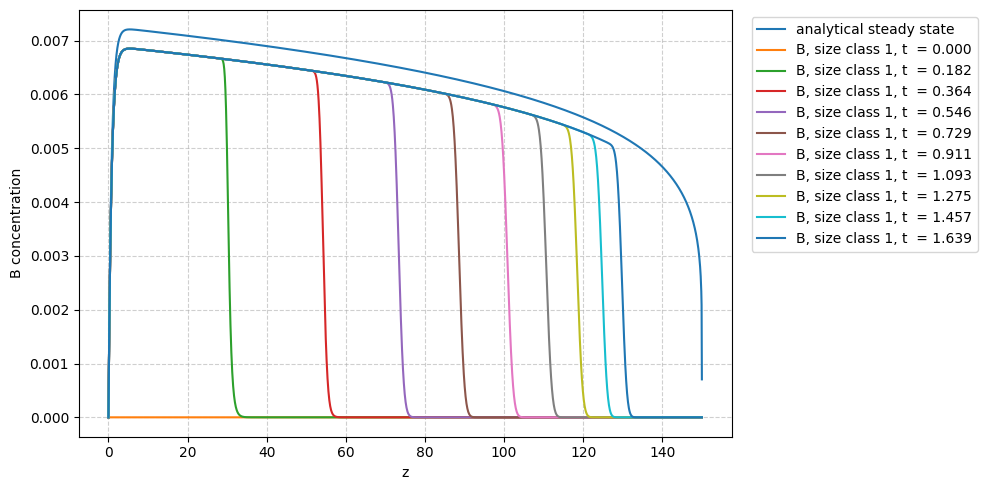

Analytical steady state range (min/max): 0.0 to 0.007207310090366714
Numerical range (min/max): 0.0 to 0.006850729025109333
Deviation of numerical from analytical at t=5.738 years: 0.005091541099215251


In [41]:
from scipy.integrate import cumulative_trapezoid
import numpy as np
import matplotlib.pyplot as plt

L=150
Nx = 2000
z = np.linspace(0,149.9999,Nx)

Dz = L/(Nx-1)
a = 61/50
alpha = 1.74
Da = 1
lambda_ = np.sqrt(alpha/Da)
u = 183 - a*z
umax = np.max(u)
kappa = 1.42 #e-2
A_st= np.exp(-lambda_*z)

B_ss = np.zeros_like(z)
integrand = A_st*u**(-kappa/a)
integral =cumulative_trapezoid(integrand, z , initial=0)
#print(f"Integral range: {integral[0]:.4f} to {integral[-1]:.4f}")
#C = -alpha*integral[-1] # this constant is determined by the boundary condition at z=L, which is B(L)=0, so we need to subtract the integral from 0 to L to ensure that B(L)=0
B_ss = u**(-1+kappa/a) * ( alpha * integral)

plt.figure(figsize=(10,5))
plt.plot(z, B_ss, label="analytical steady state")

# numerics
T=np.linspace(0.0000002*L/umax, 2*L/umax, 10)
bsol = np.zeros((len(z), len(T)))
dt = 0.99 * Dz / umax
for i in range(len(T)):
    b = np.zeros_like(z)
    bsol[:,i] = b_solver(b, alpha, kappa, A_st, Dz, T[i], dt)
    plt.plot(z, bsol[:,i], label=f"B, size class 1, t  = {T[i]:.3f}")

plt.grid(True, which="both", linestyle="--", alpha=0.6)

# labels
plt.xlabel("z")
plt.ylabel("B concentration")

plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

# adjust layout so legend fits
plt.tight_layout()
plt.show()
print("Analytical steady state range (min/max):", min(B_ss[:]), "to", max(B_ss[:]))
print("Numerical range (min/max):", min(bsol[:, 0]), "to", max(bsol[:, -1]))
print("Deviation of numerical from analytical at t=5.738 years:", np.max(np.abs(bsol[:, -1] - B_ss)))